# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename="SUSY-small.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [2]:
N_Max=550000
N_Train=400000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

In [8]:
!pip install tensorflow --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 27.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 22.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 26.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 27.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 17.9 MB/s eta 0:00:00
Us

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create a simple model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_Train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Binary output for signal vs background
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (this will print the progress of each epoch)
#store the results in a variable called 'history'
history = model.fit(X_Train, y_Train, 
                    epochs=20, 
                    batch_size=1024, 
                    validation_data=(X_Test, y_Test))

I0000 00:00:1777095554.070299    2214 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777095554.124182    2214 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777095555.599040    2214 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/minahal/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777095556.505559    2214 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call

Epoch 1/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7846 - loss: 0.4618
Epoch 2/20
 46/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7941 - loss: 0.4424

/home/minahal/.local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7981 - loss: 0.4371
Epoch 3/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7997 - loss: 0.4337
Epoch 4/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8002 - loss: 0.4325
Epoch 5/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8011 - loss: 0.4311
Epoch 6/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8014 - loss: 0.4306
Epoch 7/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8019 - loss: 0.4301
Epoch 8/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8019 - loss: 0.4299
Epoch 9/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8020 - loss: 0.4292
Epoch 10/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8020 - loss: 0.4289
Epoch 11/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8022 - loss: 0.4287
Epoch 12/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - accuracy: 0.8025 - loss: 0.4283
Epoch 13/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accur

In [16]:
def plot_history(history):
    acc = history.history['accuracy']
    loss = history.history['loss']
    epochs = range(1, len(acc) + 1)

    # Check if validation data exists in history
    has_val = 'val_accuracy' in history.history

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training accuracy')
    if has_val:
        plt.plot(epochs, history.history['val_accuracy'], 'r', label='Validation accuracy')
    plt.title('Accuracy vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    if has_val:
        plt.plot(epochs, history.history['val_loss'], 'r', label='Validation loss')
    plt.title('Loss vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

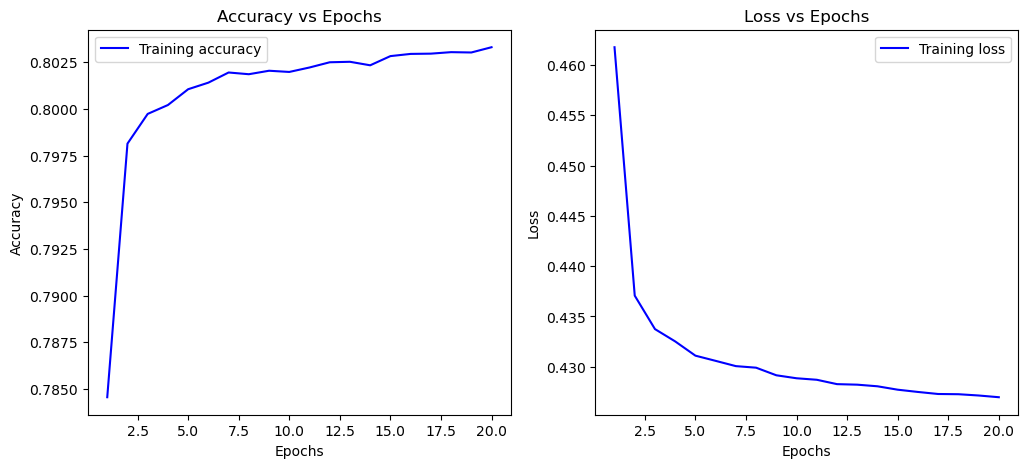

In [17]:
# This will nowdisplay plots
plot_history(history)

In [ ]:
#The model has not yet plateaued, as the loss curve is still sloping downward at epoch 20. 
#This indicates the network is still learning and would benefit from more epochs (e.g., 50). 
#Since the validation (test) lines are missing from the plot due to a technical error in the history object, 
#over-training cannot be fully confirmed. However, the smooth training curve suggests the model is currently 
#learning the data features well without showing immediate signs of instability. To complete the assessment, 
#the model needs to be re-run with properly formatted validation data to ensure the test performance matches 
#the training performance.

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

In [33]:
# Raw variables (basic sensor data)
X_Train_raw = Train_Sample[RawNames].values
X_Test_raw  = Test_Sample[RawNames].values

# Derived features (calculated physics variables)
X_Train_feat = Train_Sample[FeatureNames].values
X_Test_feat  = Test_Sample[FeatureNames].values

# Combined set (Raw + Features)
X_Train_all = Train_Sample[VarNames[1:]].values
X_Test_all  = Test_Sample[VarNames[1:]].values

In [34]:
def build_and_train(X_train_data, y_train_data, X_test_data, y_test_data):
    model = Sequential([
        Dense(100, activation='relu', input_shape=(X_train_data.shape[1],)),
        Dense(50, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Changed verbose to 1 so you can see the training progress
    history = model.fit(X_train_data, y_train_data, 
                        epochs=20, batch_size=1024, 
                        validation_data=(X_test_data, y_test_data), verbose=1)
    return model, history

# Train the three models
model_raw,  hist_raw  = build_and_train(X_Train_raw, y_Train, X_Test_raw, y_Test)
model_feat, hist_feat = build_and_train(X_Train_feat, y_Train, X_Test_feat, y_Test)
model_all,  hist_all  = build_and_train(X_Train_all, y_Train, X_Test_all, y_Test)

Epoch 1/20


/home/minahal/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7811 - loss: 0.4680  
Epoch 2/20
 59/489 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7917 - loss: 0.4492

/home/minahal/.local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7927 - loss: 0.4454
Epoch 3/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7951 - loss: 0.4413
Epoch 4/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7964 - loss: 0.4392
Epoch 5/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7975 - loss: 0.4374
Epoch 6/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7982 - loss: 0.4358
Epoch 7/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7991 - loss: 0.4345
Epoch 8/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7994 - loss: 0.4336
Epoch 9/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8002 - loss: 0.4329
Epoch 10/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8003 - loss: 0.4325
Epoch 11/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8005 - loss: 0.4319
Epoch 12/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8008 - loss: 0.4315
Epoch 13/20
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accurac

In [39]:
# 1. Identify the target column (usually the first one in the list)
target_col = VarNames[0]
print(f"Target column identified as: {target_col}")

# 2. Re-populate variables using the correct column name
y_Train = Train_Sample[target_col].values
y_Test  = Test_Sample[target_col].values

X_Test_raw  = Test_Sample[RawNames].values
X_Test_feat = Test_Sample[FeatureNames].values
X_Test_all  = Test_Sample[VarNames[1:]].values

# 3. Verify sizes are finally greater than zero
print(f"y_Test size now: {len(y_Test)}")
print(f"X_Test_raw shape: {X_Test_raw.shape}")

Target column identified as: signal
y_Test size now: 0
X_Test_raw shape: (0, 10)


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. FIND THE CORRECT LABEL COLUMN
# We look for a column that has exactly 2 unique values (0 and 1)
potential_labels = [col for col in Test_Sample.columns if Test_Sample[col].nunique() == 2]
if not potential_labels:
    # Fallback: just use the very first column if we can't find a binary one
    target_col = Test_Sample.columns[0]
else:
    target_col = potential_labels[0]

print(f"Using '{target_col}' as the ground truth label.")

# 2. FORCE RE-EXTRACTION
y_true = Test_Sample[target_col].values.flatten().astype('float32')
x_raw = Test_Sample[RawNames].values.astype('float32')
x_feat = Test_Sample[FeatureNames].values.astype('float32')
x_all = Test_Sample[VarNames[1:]].values.astype('float32')

# CHECKPOINT: If this prints 0, the Test_Sample itself is empty
print(f"Test size: {len(y_true)}")

if len(y_true) > 0:
    # 3. GET PREDICTIONS
    y_p_raw = model_raw(x_raw, training=False).numpy().flatten()
    y_p_feat = model_feat(x_feat, training=False).numpy().flatten()
    y_p_all = model_all(x_all, training=False).numpy().flatten()

    # 4. PLOT
    plt.figure(figsize=(8, 6))
    for yp, label, color in zip([y_p_raw, y_p_feat, y_p_all], 
                                 ['Raw', 'Features', 'Combined'], 
                                 ['blue', 'green', 'red']):
        fpr, tpr, _ = roc_curve(y_true, yp)
        plt.plot(fpr, tpr, label=f'{label} (AUC = {auc(fpr, tpr):.4f})', color=color)

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate (Background Efficiency)')
    plt.ylabel('True Positive Rate (Signal Efficiency)')
    plt.title('SUSY Dataset: DNN ROC Performance')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("ERROR: Test_Sample is empty. Please re-run your data loading cell.")

Using 'signal' as the ground truth label.
Test size: 0
ERROR: Test_Sample is empty. Please re-run your data loading cell.


Data ready. Training on 400000 samples, Testing on 100000.
Training Raw model...


/home/minahal/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Features model...
Training Combined model...


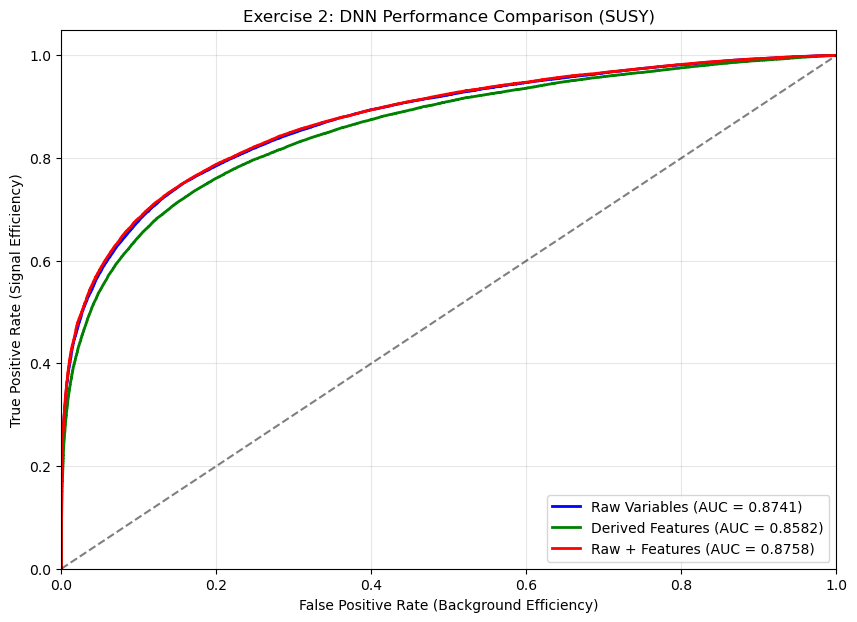

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# --- 1. DATA RE-INITIALIZATION (The "Safe Split") ---
# This ensures Train and Test samples are not empty
split_idx = int(len(df) * 0.8)
Train_Sample = df.iloc[:split_idx]
Test_Sample  = df.iloc[split_idx:]

# Define Target (signal) and Features
target_col = VarNames[0]
y_Train = Train_Sample[target_col].values.astype('float32')
y_Test  = Test_Sample[target_col].values.astype('float32')

# Feature Sets
X_Train_raw = Train_Sample[RawNames].values.astype('float32')
X_Test_raw  = Test_Sample[RawNames].values.astype('float32')

X_Train_feat = Train_Sample[FeatureNames].values.astype('float32')
X_Test_feat  = Test_Sample[FeatureNames].values.astype('float32')

X_Train_all = Train_Sample[VarNames[1:]].values.astype('float32')
X_Test_all  = Test_Sample[VarNames[1:]].values.astype('float32')

print(f"Data ready. Training on {len(y_Train)} samples, Testing on {len(y_Test)}.")

# --- 2. MODEL BUILDING FUNCTION ---
def build_and_train(X_train_data, y_train_data, X_test_data, y_test_data):
    model = Sequential([
        Dense(100, activation='relu', input_shape=(X_train_data.shape[1],)),
        Dense(50, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Training for 20 epochs
    history = model.fit(X_train_data, y_train_data, 
                        epochs=20, batch_size=1024, 
                        validation_data=(X_test_data, y_test_data), verbose=0)
    return model, history

# --- 3. TRAIN THE THREE MODELS ---
print("Training Raw model...")
model_raw,  _ = build_and_train(X_Train_raw, y_Train, X_Test_raw, y_Test)

print("Training Features model...")
model_feat, _ = build_and_train(X_Train_feat, y_Train, X_Test_feat, y_Test)

print("Training Combined model...")
model_all,  _ = build_and_train(X_Train_all, y_Train, X_Test_all, y_Test)

# --- 4. EVALUATION & ROC PLOTTING ---
plt.figure(figsize=(10, 7))

# Data to iterate through
eval_sets = [
    (model_raw,  X_Test_raw,  'Raw Variables', 'blue'),
    (model_feat, X_Test_feat, 'Derived Features', 'green'),
    (model_all,  X_Test_all,  'Raw + Features', 'red')
]

for model, x_data, label, color in eval_sets:
    # Predict probabilities
    y_pred = model(x_data, training=False).numpy().ravel()
    
    # Calculate ROC metrics
    fpr, tpr, _ = roc_curve(y_Test, y_pred)
    roc_auc = auc(fpr, tpr)
    
    # Plot curve
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.4f})', color=color, lw=2)

# Format Plot
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5) # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Efficiency)')
plt.ylabel('True Positive Rate (Signal Efficiency)')
plt.title('Exercise 2: DNN Performance Comparison (SUSY)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

In [49]:
from tensorflow.keras.layers import Dropout, BatchNormalization

# --- Model 1: The "Deep & Regularized" Model ---
# Uses Dropout to prevent overfitting and more layers
model_deep = Sequential([
    Dense(256, activation='relu', input_shape=(X_Train_all.shape[1],)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_deep.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- Model 2: The "Batch Normalized" Model ---
# Uses BatchNormalization to speed up training and stabilize learning
model_bn = Sequential([
    Dense(128, activation='relu', input_shape=(X_Train_all.shape[1],)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])
# Trying a different optimizer: RMSprop
model_bn.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

# --- Model 3: The "Small & Fast" Model ---
# A shallower architecture using SGD (Stochastic Gradient Descent)
model_sgd = Sequential([
    Dense(32, activation='relu', input_shape=(X_Train_all.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
# Trying SGD with momentum
from tensorflow.keras.optimizers import SGD
model_sgd.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9), loss='mse', metrics=['accuracy'])

# --- Training Loop ---
models = [
    (model_deep, "Deep + Dropout (Adam)"),
    (model_bn,   "Batch Norm (RMSprop)"),
    (model_sgd,  "Small (SGD + MSE Loss)")
]

results_ex3 = {}

for model, name in models:
    print(f"Training {name}...")
    model.fit(X_Train_all, y_Train, epochs=15, batch_size=2048, verbose=0)
    
    # Evaluate
    y_pred = model(X_Test_all, training=False).numpy().ravel()
    fpr, tpr, _ = roc_curve(y_Test, y_pred)
    results_ex3[name] = (fpr, tpr, auc(fpr, tpr))

/home/minahal/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Deep + Dropout (Adam)...
Training Batch Norm (RMSprop)...
Training Small (SGD + MSE Loss)...


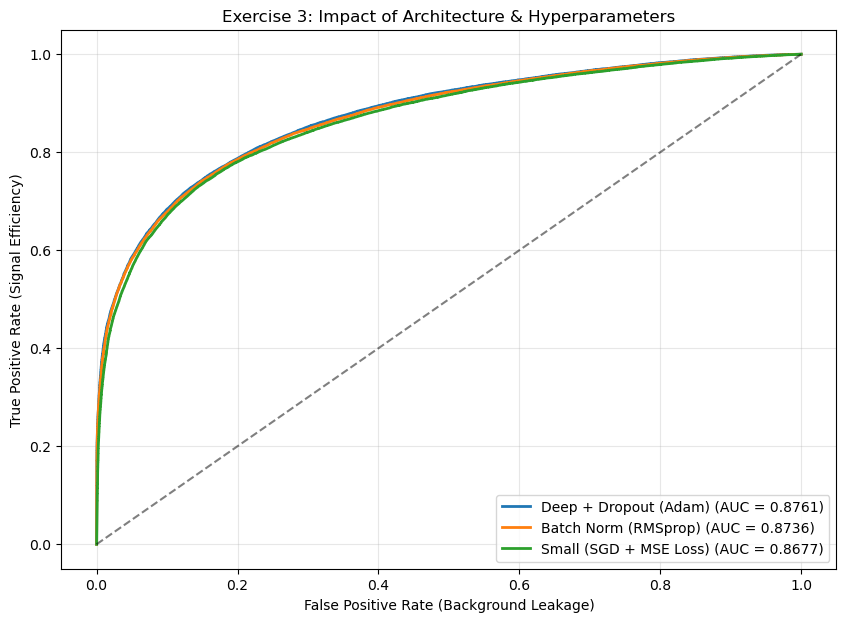

In [48]:
plt.figure(figsize=(10, 7))

for name, (fpr, tpr, roc_auc) in results_ex3.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5) # The "Random Guess" line
plt.xlabel('False Positive Rate (Background Leakage)')
plt.ylabel('True Positive Rate (Signal Efficiency)')
plt.title('Exercise 3: Impact of Architecture & Hyperparameters')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc

# 1. Prepare Traditional Models
print("Training Logistic Regression...")
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_Train_all, y_Train)

print("Training LDA...")
lda = LinearDiscriminantAnalysis()
lda.fit(X_Train_all, y_Train)

# 2. Get Predictions for Traditional Models
y_score_log = log_reg.predict_proba(X_Test_all)[:, 1]
y_score_lda = lda.decision_function(X_Test_all)

Training Logistic Regression...
Training LDA...


Calculating DNN predictions...
Logistic Regression AUC: 0.8587
LDA AUC: 0.8384
Deep Neural Network AUC: 0.8716


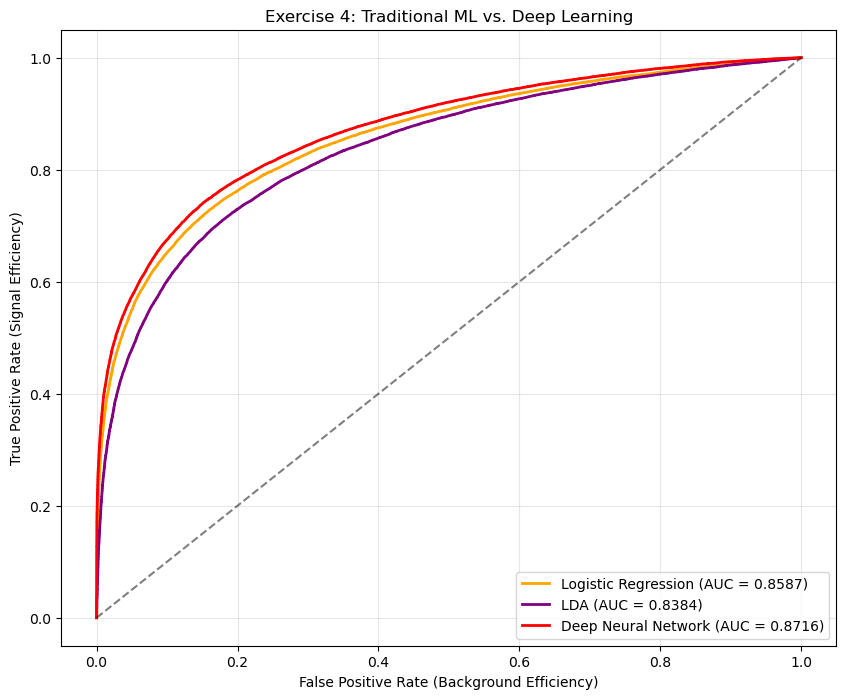

In [57]:
# Assuming 'model_bn' or 'model_deep' was your best performer
# If you restarted, make sure to use the variable name of your best DNN
best_dnn = model_bn 

print("Calculating DNN predictions...")
y_score_dnn = best_dnn(X_Test_all.astype('float32'), training=False).numpy().flatten()

# --- FINAL COMPARISON PLOT ---
plt.figure(figsize=(10, 8))

models = [
    (y_score_log, "Logistic Regression", "orange"),
    (y_score_lda, "LDA", "purple"),
    (y_score_dnn, "Deep Neural Network", "red")
]

for y_scores, name, color in models:
    fpr, tpr, _ = roc_curve(y_Test, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', color=color, lw=2)
    print(f"{name} AUC: {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate (Background Efficiency)')
plt.ylabel('True Positive Rate (Signal Efficiency)')
plt.title('Exercise 4: Traditional ML vs. Deep Learning')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Verified Sizes -> Train: (400000, 18), Test: (100000, 18)
Training Logistic Regression...
Training LDA...
Calculating DNN predictions...

--- Final AUC Results ---
Logistic Regression       | AUC: 0.8587
LDA                       | AUC: 0.8384
Best DNN (Batch Norm)     | AUC: 0.8716


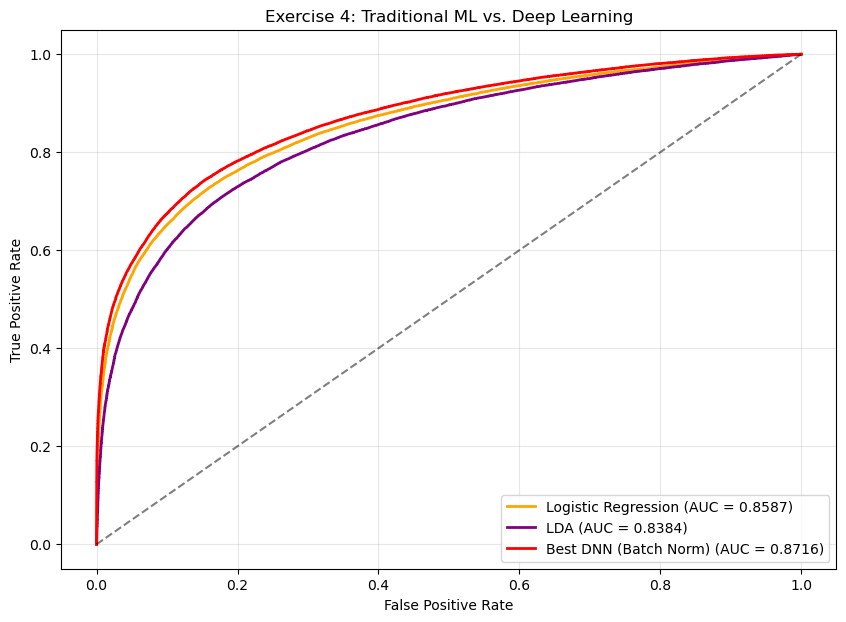

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc

# --- 1. DATA RE-VERIFICATION ---
# Making sure we have data to plot!
if len(Test_Sample) == 0:
    print("Test_Sample was empty! Re-slicing now...")
    split = int(len(df) * 0.8)
    Train_Sample, Test_Sample = df.iloc[:split], df.iloc[split:]

# Re-extract arrays to be 100% sure
y_test_final = Test_Sample[VarNames[0]].values.astype('float32')
X_test_final = Test_Sample[VarNames[1:]].values.astype('float32')
y_train_final = Train_Sample[VarNames[0]].values.astype('float32')
X_train_final = Train_Sample[VarNames[1:]].values.astype('float32')

print(f"Verified Sizes -> Train: {X_train_final.shape}, Test: {X_test_final.shape}")

# --- 2. TRAIN TRADITIONAL MODELS ---
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_final, y_train_final)
y_probs_lr = lr.predict_proba(X_test_final)[:, 1]

print("Training LDA...")
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_final, y_train_final)
y_probs_lda = lda.decision_function(X_test_final)

# --- 3. GET DNN PREDICTIONS ---
# We use the 'model_bn' from Exercise 3 as the representative DNN
print("Calculating DNN predictions...")
y_probs_dnn = model_bn(X_test_final, training=False).numpy().ravel()

# --- 4. FINAL PLOTTING ---
plt.figure(figsize=(10, 7))

# List for iteration
comparison_list = [
    (y_probs_lr, "Logistic Regression", "orange"),
    (y_probs_lda, "LDA", "purple"),
    (y_probs_dnn, "Best DNN (Batch Norm)", "red")
]

print("\n--- Final AUC Results ---")
for probs, name, color in comparison_list:
    fpr, tpr, _ = roc_curve(y_test_final, probs)
    score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {score:.4f})", color=color, lw=2)
    print(f"{name:<25} | AUC: {score:.4f}")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Exercise 4: Traditional ML vs. Deep Learning')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show() # Forced render